# Notebook de documentacion, tratamiento datos y entrenamiento


## Equipo
- Alumno 1 : 
- Alumno 2 :

In [ ]:
## TO-DO utiliza esta notebook para documentar, entrenar y probar el modelo.

## 0. Configuración e imports

In [ ]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from PIL import Image
import seaborn as sns
from sklearn.manifold import TSNE
from facenet_pytorch import MTCNN, InceptionResnetV1
import matplotlib.patches as patches

# ── Dispositivo ───────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")
if device.type == 'cuda':
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM disponible: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")



Dispositivo: cuda
GPU: NVIDIA GeForce RTX 4060 Ti
VRAM disponible: 17.2 GB


### Vista previa del dataset

In [83]:
DATASET_PATH = Path('src\data\dataset_TP1')

In [84]:
# ── Listar personas y contar fotos ────────────────────────────────────────────
personas = sorted([p.name for p in DATASET_PATH.iterdir() if p.is_dir()]) # recorre el las carpetas dentro de dataset y guarda una lista nombres de las carpetas (personas)
conteo   = {p: len(list((DATASET_PATH / p).glob("*.jpg")))for p in personas} # diccionario {persona : cantidad de fotos}

print(f"Total de personas: {len(personas)}")
print(f"Total de imágenes: {sum(conteo.values())}")
print("\nImágenes por persona:")
for nombre, cantidad in conteo.items():
    print(f"  {nombre:15}: {cantidad} fotos")

Total de personas: 9
Total de imágenes: 145

Imágenes por persona:
  canapino       : 17 fotos
  chapur         : 17 fotos
  lambiris       : 13 fotos
  ledesma        : 15 fotos
  pernia         : 17 fotos
  rossi          : 17 fotos
  santero        : 17 fotos
  todino         : 15 fotos
  werner         : 17 fotos


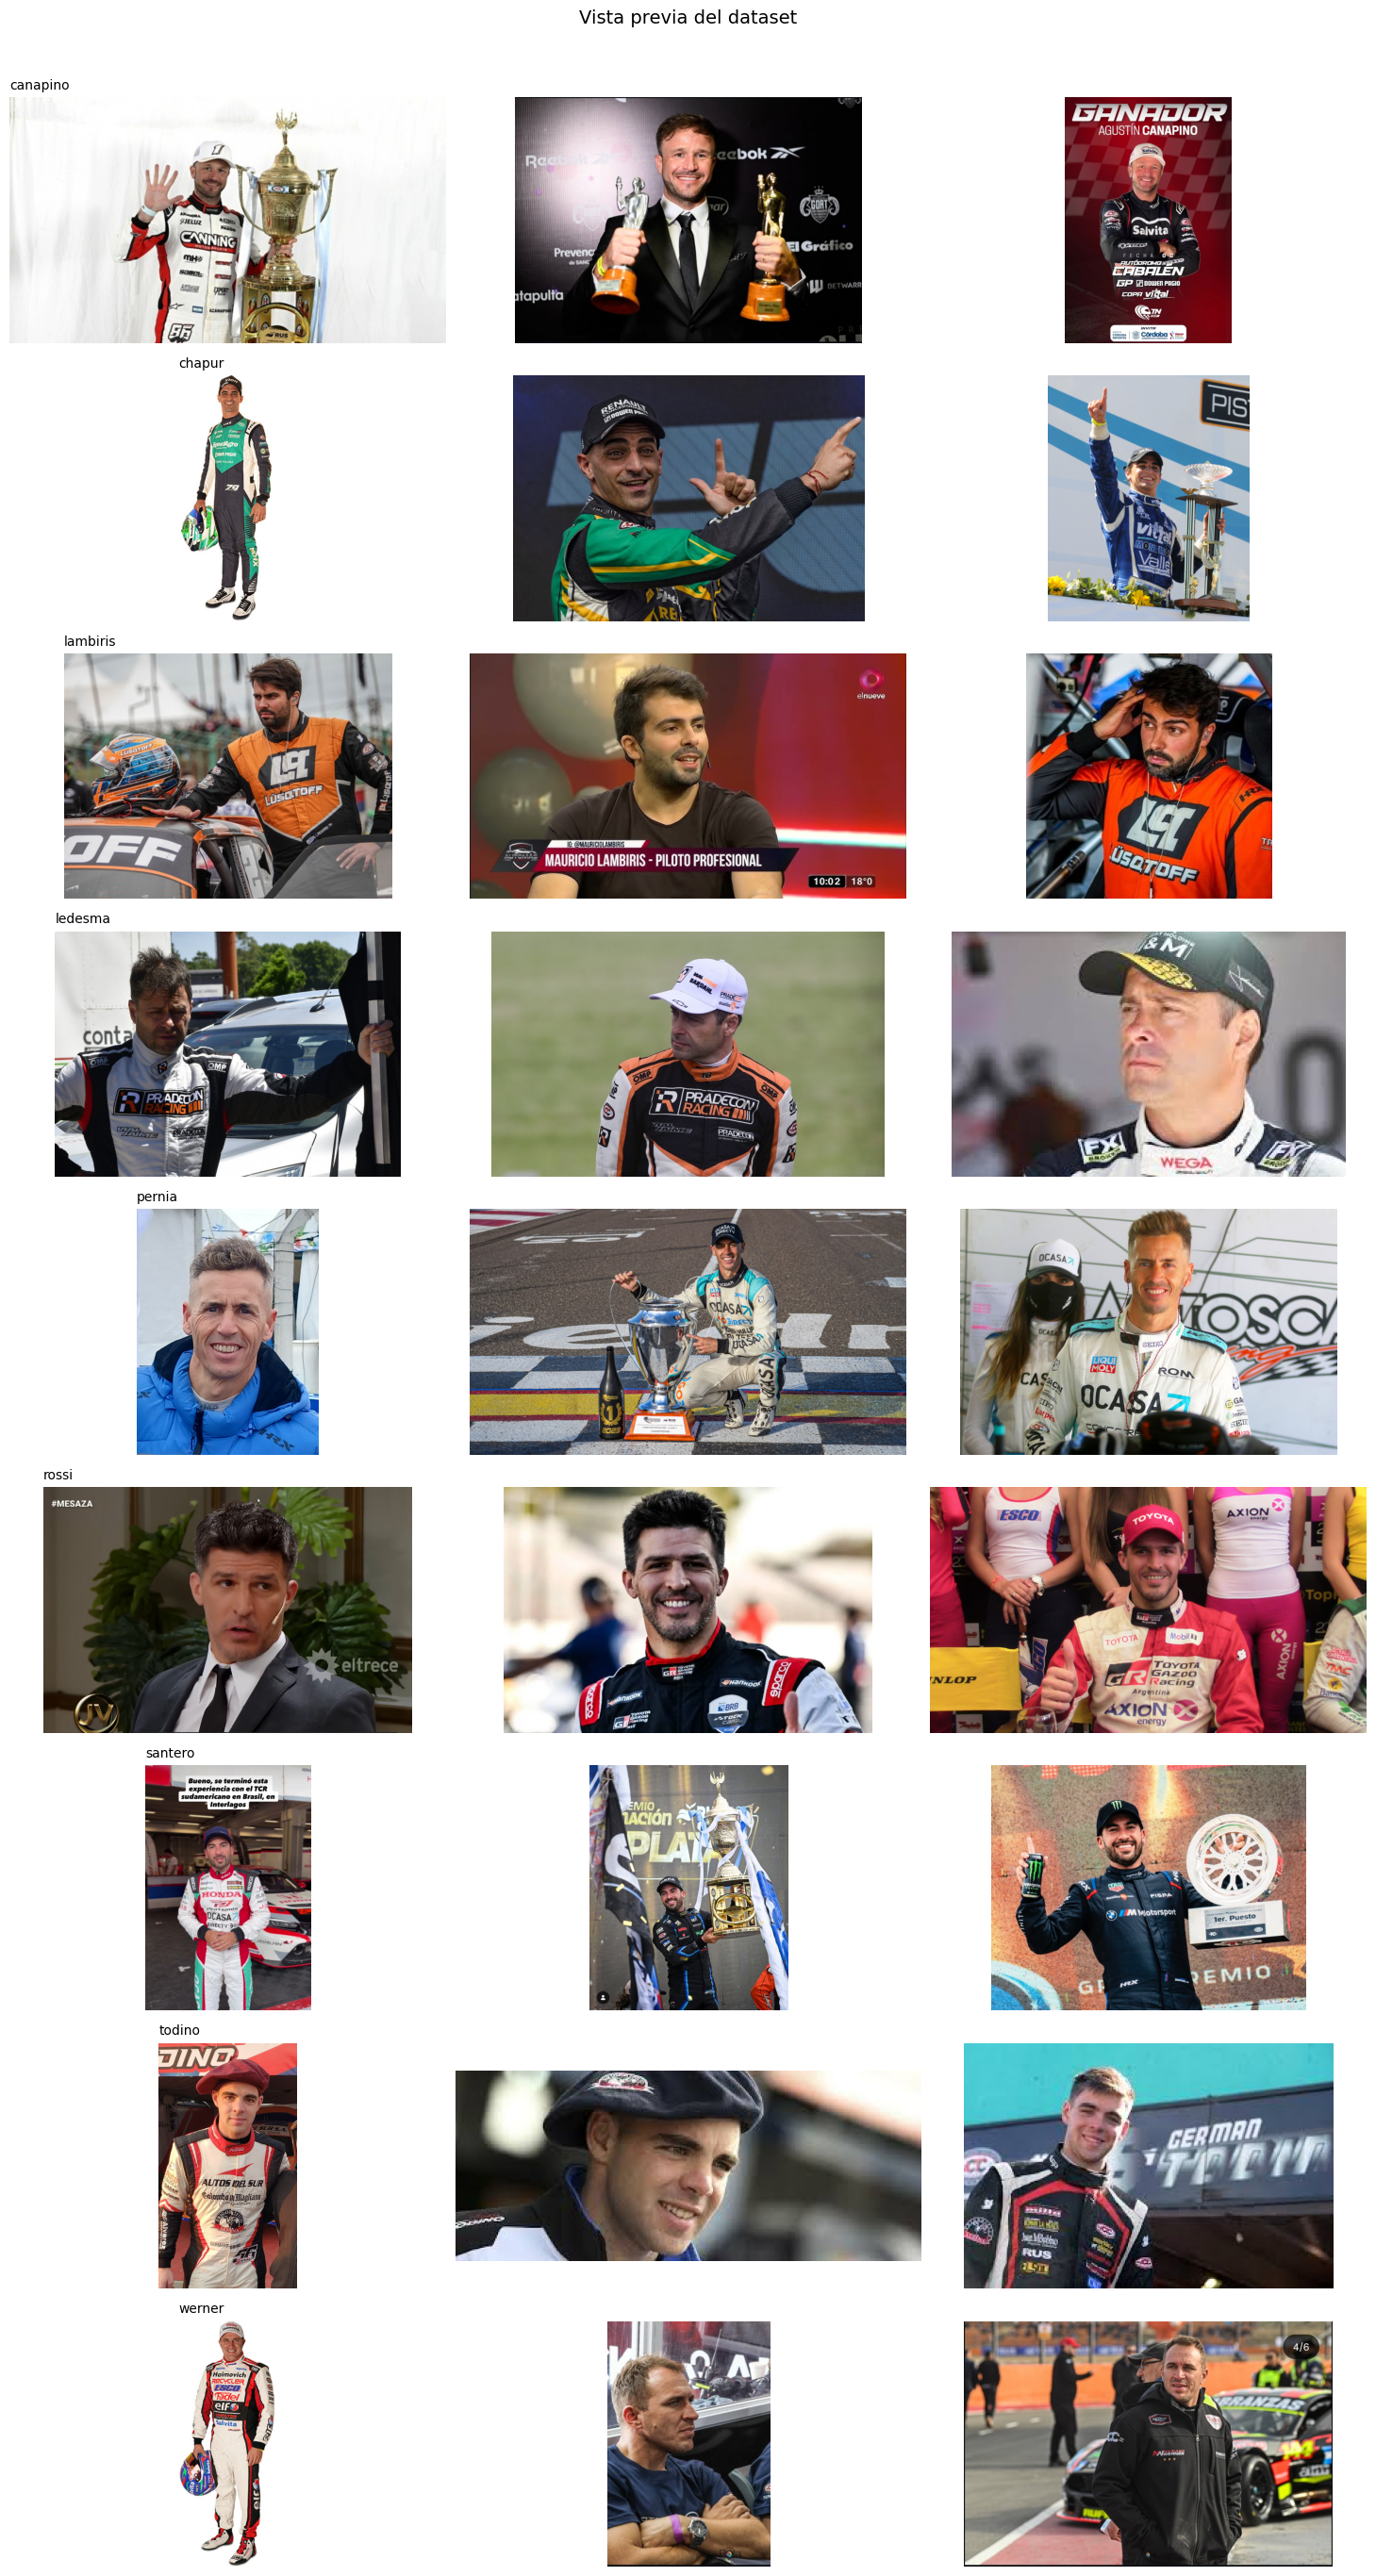

In [85]:
# ── Mostrar una muestra de imágenes por persona ───────────────────────────────
n_personas = len(personas)
fig, axes = plt.subplots(n_personas, 3, figsize=(15, 3 * n_personas))


for i, persona in enumerate(personas):
    fotos = list((DATASET_PATH / persona).glob("*.[jp][pn]g"))[:3]
    for j, foto in enumerate(fotos):
        img = Image.open(foto).convert('RGB')
        axes[i, j].imshow(img)
        axes[i, j].axis('off')
        if j == 0:
            axes[i, j].set_title(persona, fontsize=10, loc='left')

plt.suptitle("Vista previa del dataset", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## 1. Deteccion y alineacion con MTCNN

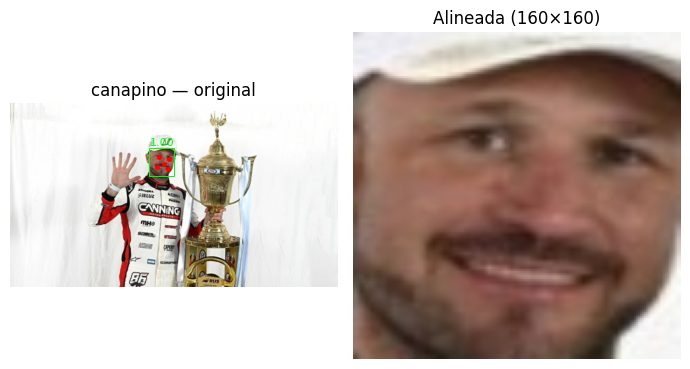

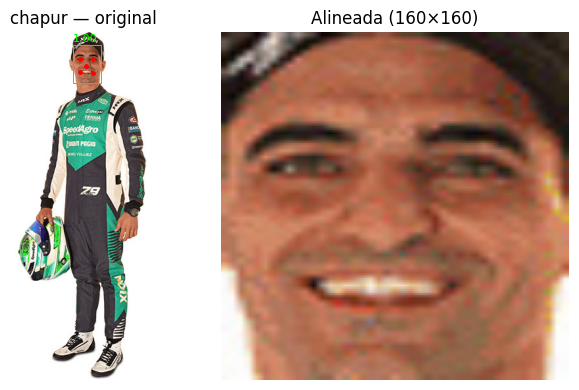

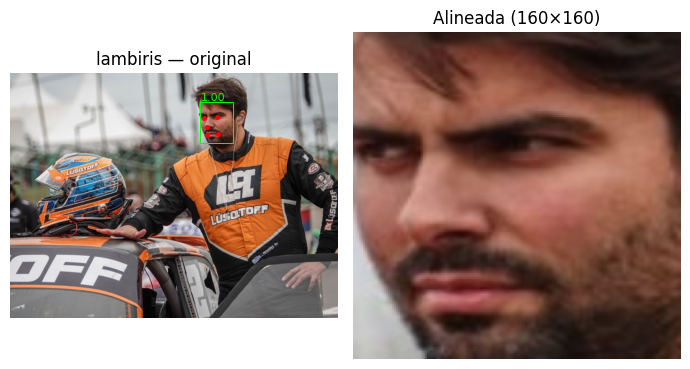

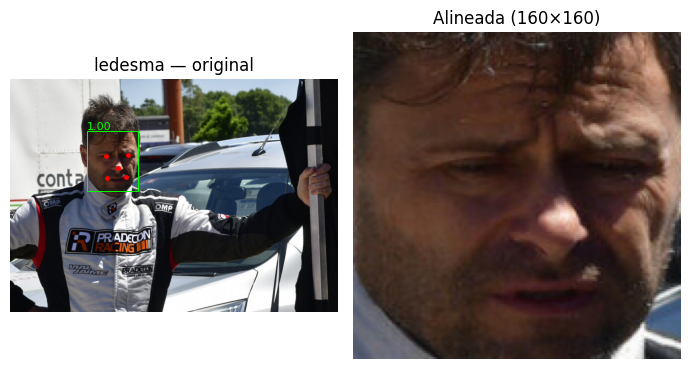

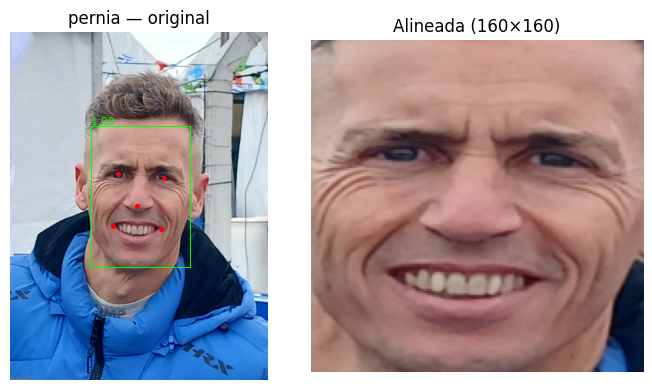

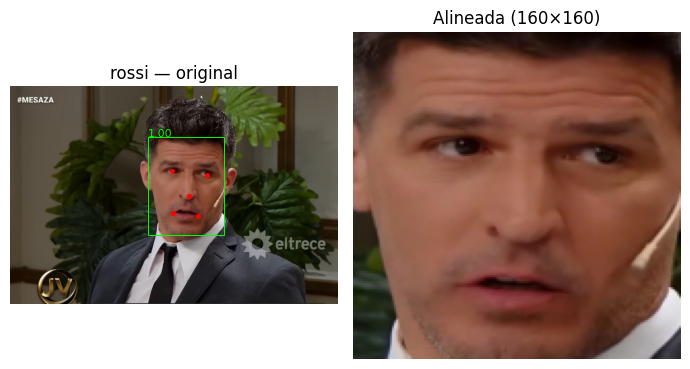

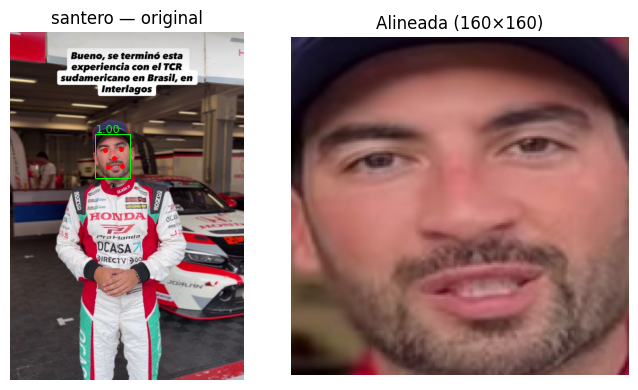

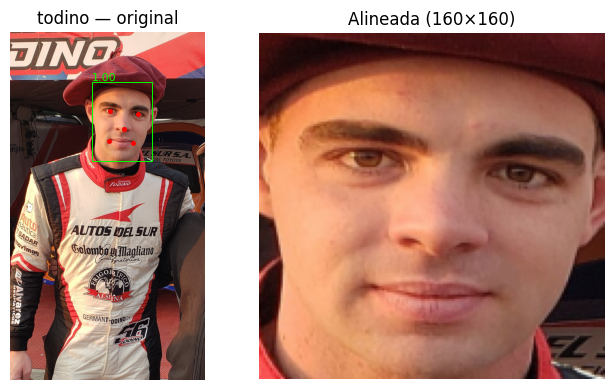

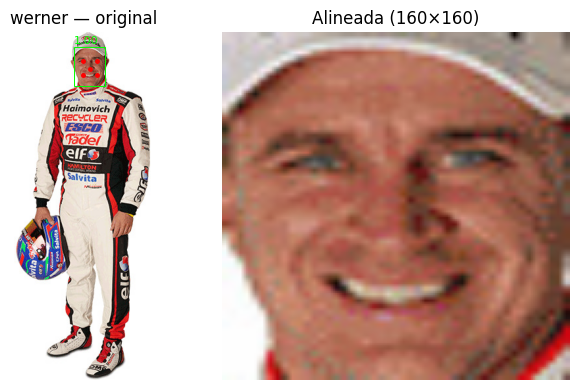


Procesamiento completo.
Sin cara detectada (0):


In [88]:
mtcnn = MTCNN(image_size=160, keep_all=False, device=device)

OUTPUT_PATH = Path('src/data/dataset_recortado')
no_detectadas = []

seen = set()
for persona in personas:
    target_dir = OUTPUT_PATH / persona
    target_dir.mkdir(parents=True, exist_ok=True)
    
    fotos = list((DATASET_PATH / persona).glob("*.jpg"))
    
    for foto_path in fotos:
        img = Image.open(foto_path).convert('RGB')
        boxes, probs, landmarks = mtcnn.detect(img, landmarks=True)
        face_tensor = mtcnn(img)  # (3, 160, 160) o None
        
        # ── Guardar imagen recortada ──────────────────────────────────────────
        if face_tensor is not None:
            face_np = ((face_tensor.permute(1, 2, 0).numpy() + 1) * 127.5).clip(0, 255).astype(np.uint8)
            Image.fromarray(face_np).save(target_dir / foto_path.name)
        else:
            no_detectadas.append(f"{persona}/{foto_path.name}")
        
        # ── Visualización: solo la primera foto de cada persona ───────────────
        if persona not in seen:
            seen.add(persona)
            fig, axes = plt.subplots(1, 2, figsize=(7, 4))
            
            # Original con bounding box y landmarks
            axes[0].imshow(img)
            axes[0].set_title(f"{persona} — original")
            axes[0].axis("off")
            
            if boxes is not None:
                x1, y1, x2, y2 = boxes[0].astype(int)
                axes[0].add_patch(
                    patches.Rectangle(
                        (x1, y1), x2 - x1, y2 - y1,
                        linewidth=0.7, edgecolor="lime", facecolor="none"
                    )
                )
                axes[0].text(x1, y1 - 5, f"{probs[0]:.2f}", color="lime", fontsize=8)
                for kp in landmarks[0]:
                    axes[0].plot(kp[0], kp[1], "r.", markersize=5)
            
            # Cara alineada
            if face_tensor is not None:
                axes[1].imshow(face_np)
                axes[1].set_title("Alineada (160×160)")
            else:
                axes[1].text(0.5, 0.5, "No detectada",
                             ha='center', va='center', transform=axes[1].transAxes,
                             fontsize=12, color='red')
                axes[1].set_title("Sin detección")
            axes[1].axis("off")
            
            plt.tight_layout()
            plt.show()

print(f"\nProcesamiento completo.")
print(f"Sin cara detectada ({len(no_detectadas)}):")
for f in no_detectadas:
    print(f"  {f}")

## 3. Data augmentation

## 4 Modelo - InceptionResnetV1

In [89]:
modelo = InceptionResnetV1(pretrained='vggface2').eval().to(device)
print(f"InceptionResnetV1 cargado | Embedding: 512 dimensiones")
print(f"Parámetros: {sum(p.numel() for p in modelo.parameters()) / 1e6:.1f}M")


def get_embedding(img_path):
    img = Image.open(img_path).convert("RGB")
    face = mtcnn(img)  # (3, 160, 160) con keep_all=False
    if face is None:
        return None
    face = face.unsqueeze(0)  # agregar dimensión batch → (1, 3, 160, 160)
    with torch.no_grad():
        return modelo(face.to(device)).cpu().numpy()[0]  # vector de 512


embeddings, emb_labels = [], []

for persona in personas:
    fotos = list((OUTPUT_PATH / persona).glob("*.jpg"))  # usamos las ya recortadas
    for foto_path in fotos:
        emb = get_embedding(foto_path)
        if emb is None:
            print(f"Sin cara: {persona}/{foto_path.name}")
            continue
        embeddings.append(emb)
        emb_labels.append(persona)
        print(f"{persona}/{foto_path.name}  norma={np.linalg.norm(emb):.4f}")

embeddings = np.array(embeddings)
print(f"\nEmbeddings: {embeddings.shape}")  # debería ser (n_fotos_total, 512)

d:\Respaldo\TUIA\Computer vision\tuia-face-recognition-app\.venv-notebook\Lib\site-packages\facenet_pytorch\models\inception_resnet_v1.py:329: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experime

InceptionResnetV1 cargado | Embedding: 512 dimensiones
Parámetros: 27.9M
canapino/foto1.jpg  norma=1.0000
canapino/foto10.jpg  norma=1.0000
canapino/foto12.jpg  norma=1.0000
canapino/foto13.jpg  norma=1.0000
canapino/foto14.jpg  norma=1.0000
canapino/foto16.jpg  norma=1.0000
canapino/foto17.jpg  norma=1.0000
canapino/foto18.jpg  norma=1.0000
canapino/foto19.jpg  norma=1.0000
canapino/foto2.jpg  norma=1.0000
canapino/foto20.jpg  norma=1.0000
canapino/foto3.jpg  norma=1.0000
canapino/foto4.jpg  norma=1.0000
canapino/foto5.jpg  norma=1.0000
canapino/foto7.jpg  norma=1.0000
canapino/foto8.jpg  norma=1.0000
canapino/foto9.jpg  norma=1.0000
chapur/foto1.jpg  norma=1.0000
chapur/foto10.jpg  norma=1.0000
chapur/foto11.jpg  norma=1.0000
chapur/foto12.jpg  norma=1.0000
chapur/foto13.jpg  norma=1.0000
chapur/foto15.jpg  norma=1.0000
chapur/foto16.jpg  norma=1.0000
chapur/foto17.jpg  norma=1.0000
chapur/foto18.jpg  norma=1.0000
chapur/foto19.jpg  norma=1.0000
chapur/foto2.jpg  norma=1.0000
chapur/

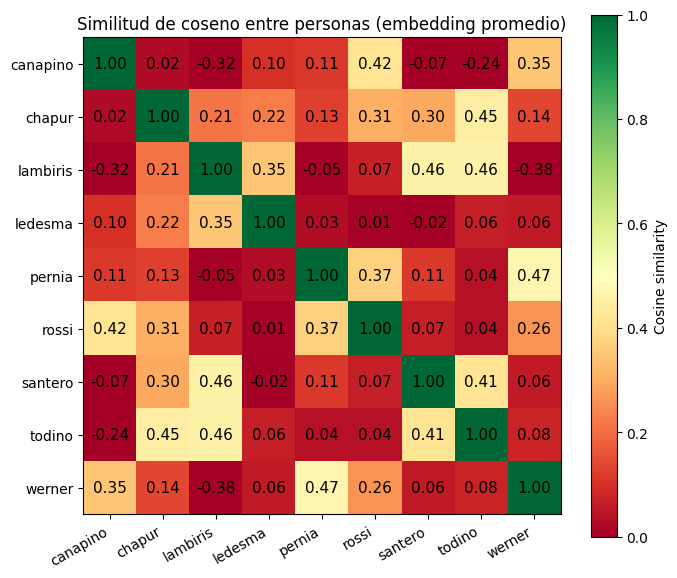

In [90]:
# Embedding promedio por persona (normalizado)
personas_unicas = sorted(set(emb_labels))
emb_promedio = {}

for persona in personas_unicas:
    indices = [i for i, l in enumerate(emb_labels) if l == persona]
    promedio = embeddings[indices].mean(axis=0)
    promedio = promedio / np.linalg.norm(promedio)  # renormalizar
    emb_promedio[persona] = promedio

nombres = list(emb_promedio.keys())
galeria = np.array(list(emb_promedio.values()))

# Matriz 5x5
sim_matrix = galeria @ galeria.T

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_matrix, cmap="RdYlGn", vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label="Cosine similarity")

ax.set_xticks(range(len(nombres)))
ax.set_yticks(range(len(nombres)))
ax.set_xticklabels(nombres, rotation=30, ha="right", fontsize=10)
ax.set_yticklabels(nombres, fontsize=10)

for i in range(len(nombres)):
    for j in range(len(nombres)):
        ax.text(j, i, f"{sim_matrix[i, j]:.2f}",
                ha="center", va="center", fontsize=11,
                color="black")

ax.set_title("Similitud de coseno entre personas (embedding promedio)")
plt.tight_layout()
plt.show()

In [91]:
import cv2
from sklearn.datasets import fetch_lfw_people
from sklearn.model_selection import train_test_split

lfw = fetch_lfw_people(min_faces_per_person=70, resize=1.0, color=True)
X_raw, y_lfw, names = lfw.images, lfw.target, lfw.target_names
print(f"LFW: {X_raw.shape[0]} imágenes, {len(names)} personas: {list(names)}")

def preprocess_lfw(imgs):
    out = []
    for img in imgs:
        arr = (img * 255).astype(np.uint8)
        arr = cv2.resize(arr, (160, 160))
        arr = (arr.astype(np.float32) - 127.5) / 128.0
        out.append(arr.transpose(2, 0, 1))
    return torch.tensor(np.array(out), dtype=torch.float32)

lfw_embs = []
BATCH = 64
for i in range(0, len(X_raw), BATCH):
    batch = preprocess_lfw(X_raw[i:i+BATCH]).to(device)  # GPU
    with torch.no_grad():
        lfw_embs.append(modelo(batch).cpu().numpy())

lfw_embs = np.vstack(lfw_embs)
print(f"Embeddings extraídos: {lfw_embs.shape}")

# Rank-1 Accuracy
X_gal, X_qry, y_gal, y_qry = train_test_split(
    lfw_embs, y_lfw, test_size=0.3, stratify=y_lfw, random_state=42
)
sims = X_qry @ X_gal.T
preds = y_gal[sims.argmax(axis=1)]
accuracy = (preds == y_qry).mean()
print(f"Rank-1 Accuracy en LFW: {accuracy:.2%}")
print("(referencia: FaceNet reporta ~99% en LFW con el modelo completo)")

LFW: 1288 imágenes, 7 personas: ['Ariel Sharon', 'Colin Powell', 'Donald Rumsfeld', 'George W Bush', 'Gerhard Schroeder', 'Hugo Chavez', 'Tony Blair']
Embeddings extraídos: (1288, 512)
Rank-1 Accuracy en LFW: 99.74%
(referencia: FaceNet reporta ~99% en LFW con el modelo completo)


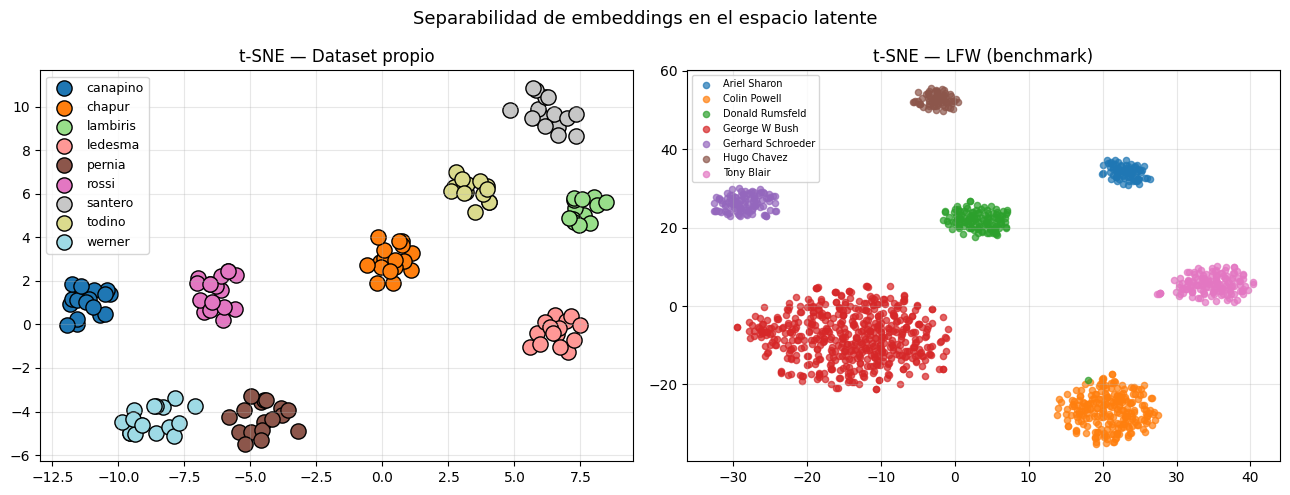

In [ ]:


fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Dataset propio ────────────────────────────────────────────────────────────
le = LabelEncoder()
y_own = le.fit_transform(emb_labels)

perp_own = min(30, len(embeddings) - 1)
tsne_own = TSNE(n_components=2, perplexity=perp_own, random_state=42)
tsne2 = tsne_own.fit_transform(embeddings)
colors = colors = plt.cm.tab20(np.linspace(0, 1, len(le.classes_)))

ax = axes[0]
for idx, cls in enumerate(le.classes_):
    mask = y_own == idx
    ax.scatter(
        tsne2[mask, 0], tsne2[mask, 1],
        label=cls, color=colors[idx], s=120, edgecolors="k"
    )
ax.set_title("t-SNE — Dataset propio")
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# ── LFW ──────────────────────────────────────────────────────────────────────
perp_lfw = min(30, len(lfw_embs) - 1)
tsne_lfw = TSNE(n_components=2, perplexity=perp_lfw, random_state=42)
tsne_lfw2 = tsne_lfw.fit_transform(lfw_embs)

ax = axes[1]
for idx in range(len(names)):
    mask = y_lfw == idx
    ax.scatter(
        tsne_lfw2[mask, 0], tsne_lfw2[mask, 1],
        label=names[idx], s=20, alpha=0.7
    )
ax.set_title("t-SNE — LFW (benchmark)")
ax.legend(fontsize=7)
ax.grid(alpha=0.3)

plt.suptitle("Separabilidad de embeddings en el espacio latente", fontsize=13)
plt.tight_layout()
plt.show()